In [1]:
# ---------------------------------------
# 1. Docstring & Imports
# ----------------------------------------

"""
Portfolio Analysis Tool
============================
Portfolio : AAPL (Tech), JPM (Financials), JNJ (Healthcare), KO (Consumer Staples), XOM (Energy)
Benchmark : ^GSPC (S&P 500)
Period    : 2015-01-01 -> today
"""

from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
# ----------------------------------
# 2. Config
# ----------------------------------

TICKERS: list[str] = ["AAPL", "JPM", "JNJ", "KO", "XOM"]
BENCHMARK: str = "^GSPC"
START_DATE: str = "2015-01-01"
TRADING_DAYS: int = 252
ALL_SYMBOLS: list[str] = TICKERS + [BENCHMARK]

WEIGHTS_EQUAL = pd.Series({"AAPL": 0.20, "JPM": 0.20, "JNJ": 0.20, "KO": 0.20, "XOM": 0.20})
WEIGHTS_DEFENSIVE = pd.Series({"AAPL": 0.15, "JPM": 0.10, "JNJ": 0.30, "KO": 0.25, "XOM": 0.20})

In [3]:
# ---------------------------------
# 3. Download & Sanity Check
# ----------------------------------

data = yf.download(ALL_SYMBOLS, start=START_DATE, auto_adjust=True)
prices = data["Close"]
print(prices.head())
print(prices.tail())

[*********************100%***********************]  6 of 6 completed

Ticker           AAPL        JNJ        JPM         KO        XOM        ^GSPC
Date                                                                          
2015-01-02  24.192600  76.110909  46.066795  29.390255  57.145550  2058.199951
2015-01-05  23.511055  75.579308  44.636646  29.390255  55.581936  2020.579956
2015-01-06  23.513273  75.207924  43.479267  29.613447  55.286461  2002.609985
2015-01-07  23.842979  76.868233  43.545609  29.983097  55.846645  2025.900024
2015-01-08  24.759077  77.472618  44.518692  30.345758  56.776180  2062.139893
Ticker            AAPL         JNJ         JPM         KO         XOM  \
Date                                                                    
2026-07-06  312.660004  259.329987  337.720001  82.959999  136.440002   
2026-07-07  310.660004  267.239990  339.220001  84.050003  141.690002   
2026-07-08  313.390015  263.399994  330.619995  83.400002  141.130005   
2026-07-09  316.220001  259.100006  335.470001  82.629997  137.460007   
2026-07-1

In [4]:
# ----------------------------------
# 4. Returns (simple + log)
# ----------------------------------

daily_simple = prices.pct_change().dropna()
daily_log = np.log(prices / prices.shift(1)).dropna()

annual_simple = daily_simple.mean() * TRADING_DAYS
annual_log = daily_log.mean() * TRADING_DAYS

annual_returns_stocks = annual_simple[TICKERS]
annual_return_benchmark = annual_simple[BENCHMARK]

print(annual_simple)

Ticker
AAPL     0.264819
JNJ      0.122700
JPM      0.209571
KO       0.106857
XOM      0.115190
^GSPC    0.129250
dtype: float64


In [5]:
# --------------------------------------------------
# 5. Portfolio Returns (dot product, label-aligned)
# --------------------------------------------------

portfolio_1 = annual_returns_stocks.dot(WEIGHTS_EQUAL)
portfolio_2 = annual_returns_stocks.dot(WEIGHTS_DEFENSIVE)

alpha_1 = portfolio_1 - annual_return_benchmark
alpha_2 = portfolio_2 - annual_return_benchmark

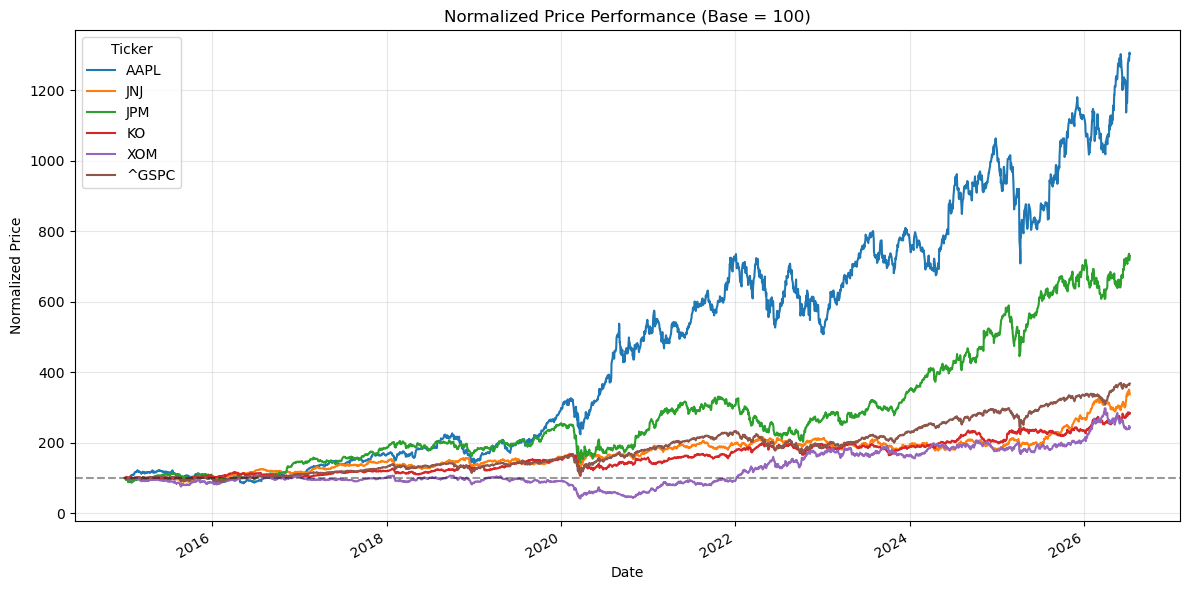

In [6]:
# -------------------------------------
# 6. Normalized Chart
# -------------------------------------

normalized = (prices / prices.iloc[0]) * 100
fig, ax = plt.subplots(figsize=(12, 6))
normalized.plot(ax=ax, linewidth=1.5)
ax.axhline(100, color="black", linestyle="--", alpha=0.4)
ax.set_title("Normalized Price Performance (Base = 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price")
ax.legend(title="Ticker")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

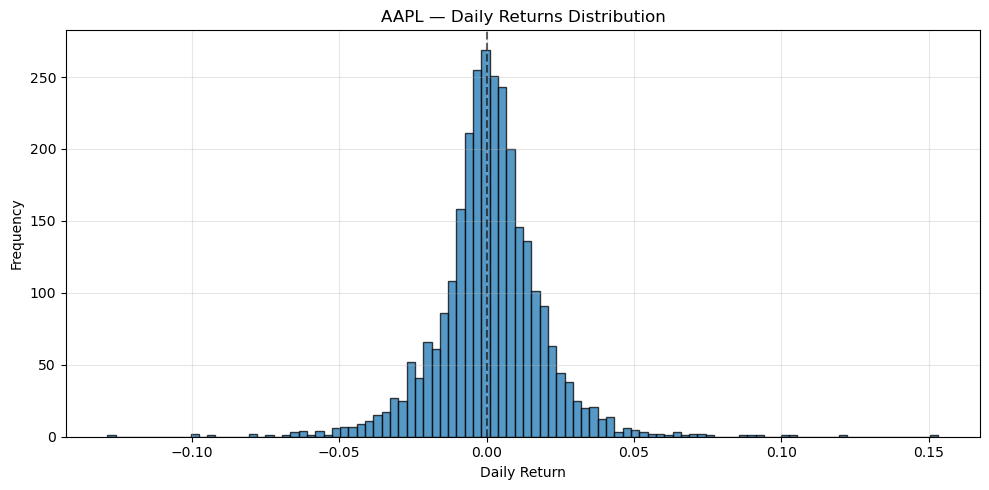

In [7]:
# --------------------------------------
# 7. Returns Distribution (AAPL)
# --------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
daily_simple["AAPL"].hist(bins=100, ax=ax, alpha=0.75, edgecolor="black")
ax.axvline(0, color="black", linestyle="--", alpha=0.6)
ax.set_title("AAPL — Daily Returns Distribution")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# ------------------------------
# 8. Report
# ------------------------------


print("=" * 50)
print("PORTFOLIO ANALYSIS REPORT")
print(f"Period: {START_DATE} -> today | Trading days/year: {TRADING_DAYS}")
print("=" * 50)

print("\n-- Annualized Returns (individual assets, simple) --")
for ticker, ret in annual_simple.items():
    print(f"  {ticker:<8}: {ret * 100:6.2f}%")

print(f"\nBenchmark (S&P 500) Annual Return: {annual_return_benchmark * 100:.2f}%")

print("\n-- Portfolio 1: Equal-Weighted (20% each) --")
print(f"  Annual Return: {portfolio_1 * 100:.2f}%")
print(f"  Alpha vs S&P 500: {alpha_1 * 100:+.2f}%")

print("\n-- Portfolio 2: Defensive-Tilted (JNJ/KO heavy) --")
print(f"  Annual Return: {portfolio_2 * 100:.2f}%")
print(f"  Alpha vs S&P 500: {alpha_2 * 100:+.2f}%")

winner = "Portfolio 1 (Equal-Weighted)" if portfolio_1 > portfolio_2 else "Portfolio 2 (Defensive)"
print(f"\nConclusion: {winner} had the higher annualized return over the period.")

PORTFOLIO ANALYSIS REPORT
Period: 2015-01-01 -> today | Trading days/year: 252

-- Annualized Returns (individual assets, simple) --
  AAPL    :  26.48%
  JNJ     :  12.27%
  JPM     :  20.96%
  KO      :  10.69%
  XOM     :  11.52%
  ^GSPC   :  12.93%

Benchmark (S&P 500) Annual Return: 12.93%

-- Portfolio 1: Equal-Weighted (20% each) --
  Annual Return: 16.38%
  Alpha vs S&P 500: +3.46%

-- Portfolio 2: Defensive-Tilted (JNJ/KO heavy) --
  Annual Return: 14.72%
  Alpha vs S&P 500: +1.80%

Conclusion: Portfolio 1 (Equal-Weighted) had the higher annualized return over the period.
